<a href="https://colab.research.google.com/github/Shraddha-Bankar/Salary_prediction/blob/main/Salary_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

In [5]:
df = pd.read_csv("/content/Salary_Dataset_DataScienceLovers.csv")
df

,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles
0,3.8,Sasken,Android Developer,400000,3,Bangalore,Full Time,Android
1,4.5,Advanced Millennium Technologies,Android Developer,400000,3,Bangalore,Full Time,Android
2,4.0,Unacademy,Android Developer,1000000,3,Bangalore,Full Time,Android
3,3.8,SnapBizz Cloudtech,Android Developer,300000,3,Bangalore,Full Time,Android
4,4.4,Appoids Tech Solutions,Android Developer,600000,3,Bangalore,Full Time,Android
...,...,...,...,...,...,...,...,...
22765,4.7,Expert Solutions,Web Developer,200000,1,Bangalore,Full Time,Web
22766,4.0,Nextgen Innovation Labs,Web Developer,300000,1,Bangalore,Full Time,Web
22767,4.1,Fresher,Full Stack Web Developer,192000,13,Bangalore,Full Time,Web
22768,4.1,Accenture,Full Stack Web Developer,300000,7,Bangalore,Full Time,Web


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22770 entries, 0 to 22769
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Rating             22770 non-null  float64
 1   Company Name       22769 non-null  object 
 2   Job Title          22770 non-null  object 
 3   Salary             22770 non-null  int64  
 4   Salaries Reported  22770 non-null  int64  
 5   Location           22770 non-null  object 
 6   Employment Status  22770 non-null  object 
 7   Job Roles          22770 non-null  object 
dtypes: float64(1), int64(2), object(5)
memory usage: 1.4+ MB


In [8]:
df.isnull().sum()

,0
Rating,0
Company Name,1
Job Title,0
Salary,0
Salaries Reported,0
Location,0
Employment Status,0
Job Roles,0


In [12]:
for column in df.columns:
  if df[column].isnull().any():
    if df[column].dtype == 'object':
      mode_value = df[column].mode()[0]
      df[column] = df[column].fillna(mode_value)
      print(f"Filled nulls in '{column}' with mode: {mode_value}")
    elif df[column].dtype in ['int64', 'float64']:
      mean_value = df[column].mean()
      df[column] = df[column].fillna(mean_value)
      print(f"Filled nulls in '{column}' with mean: {mean_value}")

In [13]:
company_name_mode = df['Company Name'].mode()[0]
job_roles_mode = df['Job Roles'].mode()[0]

df['Company Name'].fillna(company_name_mode, inplace=True)
df['Job Roles'].fillna(job_roles_mode, inplace=True)

df.isnull().sum()

/tmp/ipykernel_1412/2692550956.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Job Roles'].fillna(job_roles_mode, inplace=True)


,0
Rating,0
Company Name,0
Job Title,0
Salary,0
Salaries Reported,0
Location,0
Employment Status,0
Job Roles,0


In [14]:
for column in df.columns:
  if df[column].dtype == 'object':
    df[column] = df[column].fillna(df[column].mode()[0])
  elif df[column].dtype in ['int64', 'float64']:
    df[column] = df[column].fillna(df[column].mean())
print(df.isnull().sum())

Rating               0
Company Name         0
Job Title            0
Salary               0
Salaries Reported    0
Location             0
Employment Status    0
Job Roles            0
dtype: int64


In [15]:
from sklearn.preprocessing import LabelEncoder

In [16]:
label_encoder = LabelEncoder()
for column in df.columns:
    if df[column].dtype == 'object':
        df[column] = label_encoder.fit_transform(df[column])
display(df.head())
df.info()

,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles
0,3.8,8129,28,400000,3,0,1,0
1,4.5,417,28,400000,3,0,1,0
2,4.0,9777,28,1000000,3,0,1,0
3,3.8,8533,28,300000,3,0,1,0
4,4.4,884,28,600000,3,0,1,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22770 entries, 0 to 22769
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Rating             22770 non-null  float64
 1   Company Name       22770 non-null  int64  
 2   Job Title          22770 non-null  int64  
 3   Salary             22770 non-null  int64  
 4   Salaries Reported  22770 non-null  int64  
 5   Location           22770 non-null  int64  
 6   Employment Status  22770 non-null  int64  
 7   Job Roles          22770 non-null  int64  
dtypes: float64(1), int64(7)
memory usage: 1.4 MB


In [20]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
22765,False
22766,False
22767,False
22768,False


In [19]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

le = LabelEncoder()

for column in df.columns:
  if df[column].dtype == 'object':
    df[column] = le.fit_transform(df[column])

display(df.head())

X = df.drop('Salary', axis=1)
y = df['Salary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles
0,3.8,8129,28,400000,3,0,1,0
1,4.5,417,28,400000,3,0,1,0
2,4.0,9777,28,1000000,3,0,1,0
3,3.8,8533,28,300000,3,0,1,0
4,4.4,884,28,600000,3,0,1,0


X_train shape: (18216, 7)
X_test shape: (4554, 7)
y_train shape: (18216,)
y_test shape: (4554,)


In [21]:
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
# For Naive Bayes, typically used for classification; for regression, GaussianNB can be adapted but is less common for direct regression.
# from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import mean_absolute_error, r2_score

results = {}

### 1. Linear Regression

In [22]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

results['Linear Regression'] = {'MAE': mae_lr, 'R2': r2_lr}

print(f"Linear Regression MAE: {mae_lr:.2f}")
print(f"Linear Regression R-squared: {r2_lr:.2f}")

Linear Regression MAE: 414592.23
Linear Regression R-squared: 0.05


### 2. Support Vector Regressor (SVR)
*Note: SVR can be computationally intensive and may take longer to run.*

In [23]:
svr_model = SVR()
svr_model.fit(X_train, y_train)

y_pred_svr = svr_model.predict(X_test)

mae_svr = mean_absolute_error(y_test, y_pred_svr)
r2_svr = r2_score(y_test, y_pred_svr)

results['SVR'] = {'MAE': mae_svr, 'R2': r2_svr}

print(f"SVR MAE: {mae_svr:.2f}")
print(f"SVR R-squared: {r2_svr:.2f}")

SVR MAE: 399705.67
SVR R-squared: -0.09


### 3. K-Nearest Neighbors Regressor (KNN)

In [24]:
knn_model = KNeighborsRegressor()
knn_model.fit(X_train, y_train)

y_pred_knn = knn_model.predict(X_test)

mae_knn = mean_absolute_error(y_test, y_pred_knn)
r2_knn = r2_score(y_test, y_pred_knn)

results['KNN'] = {'MAE': mae_knn, 'R2': r2_knn}

print(f"KNN MAE: {mae_knn:.2f}")
print(f"KNN R-squared: {r2_knn:.2f}")

KNN MAE: 435853.00
KNN R-squared: -0.53


### 4. Decision Tree Regressor

In [25]:
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

mae_dt = mean_absolute_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)

results['Decision Tree'] = {'MAE': mae_dt, 'R2': r2_dt}

print(f"Decision Tree MAE: {mae_dt:.2f}")
print(f"Decision Tree R-squared: {r2_dt:.2f}")

Decision Tree MAE: 526871.46
Decision Tree R-squared: -5.13


### 5. Random Forest Regressor

In [26]:
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

results['Random Forest'] = {'MAE': mae_rf, 'R2': r2_rf}

print(f"Random Forest MAE: {mae_rf:.2f}")
print(f"Random Forest R-squared: {r2_rf:.2f}")

Random Forest MAE: 399743.10
Random Forest R-squared: -0.54


### 6. Naive Bayes
*Note: Naive Bayes models (like GaussianNB) are primarily designed for classification tasks. While they can be adapted for regression, they are not typically used directly for predicting continuous target variables like salary. If you'd like to explore this, we would need to discretize the 'Salary' column into categories first.*

### Summary of Model Performance

In [28]:
import pandas as pd
results_df = pd.DataFrame(results).T.sort_values(by='MAE')
display(results_df)

,MAE,R2
SVR,399705.666771,-0.087549
Random Forest,399743.102890,-0.538862
Linear Regression,414592.233988,0.046720
KNN,435852.998858,-0.530455
Decision Tree,526871.455424,-5.126940


In [29]:
display(results_df)

,MAE,R2
SVR,399705.666771,-0.087549
Random Forest,399743.102890,-0.538862
Linear Regression,414592.233988,0.046720
KNN,435852.998858,-0.530455
Decision Tree,526871.455424,-5.126940


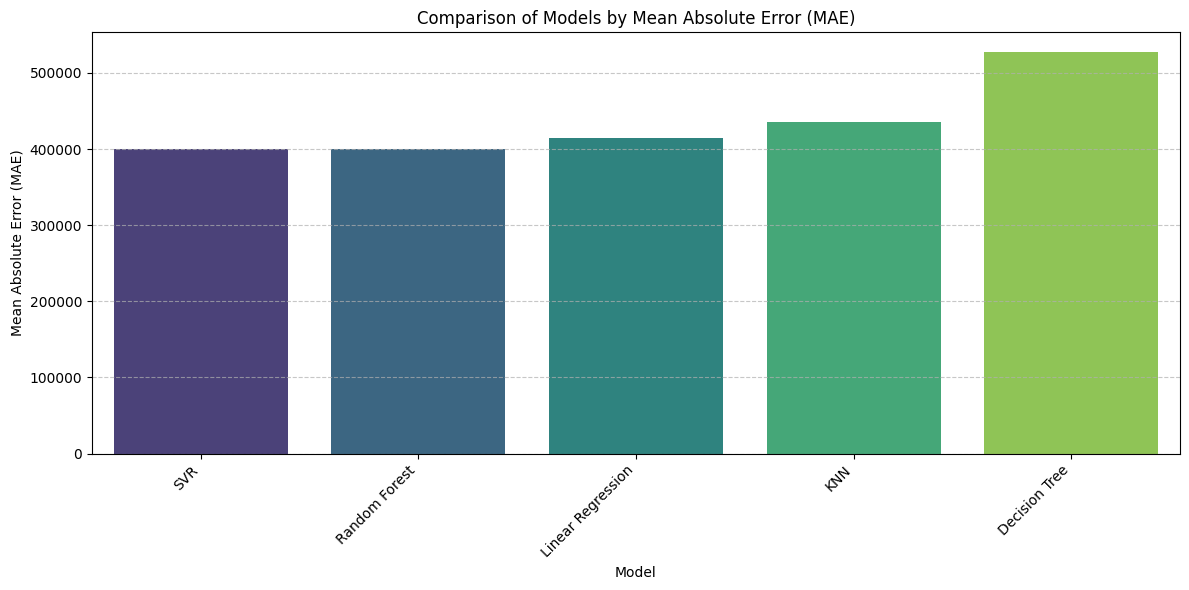

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for plotting (MAE)
mae_data = results_df['MAE'].reset_index()
mae_data.columns = ['Model', 'MAE']

plt.figure(figsize=(12, 6))
sns.barplot(x='Model', y='MAE', data=mae_data.sort_values(by='MAE', ascending=True), hue='Model', palette='viridis', legend=False)
plt.title('Comparison of Models by Mean Absolute Error (MAE)')
plt.xlabel('Model')
plt.ylabel('Mean Absolute Error (MAE)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

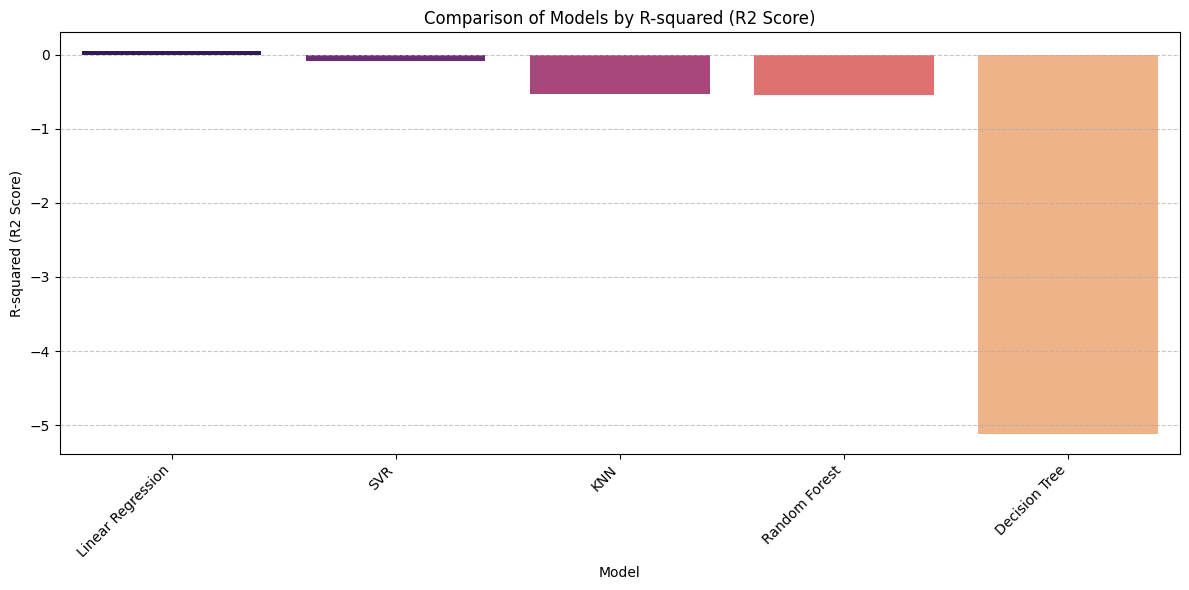

In [33]:
# Prepare data for plotting (R2 Score)
r2_data = results_df['R2'].reset_index()
r2_data.columns = ['Model', 'R2']

plt.figure(figsize=(12, 6))
sns.barplot(x='Model', y='R2', data=r2_data.sort_values(by='R2', ascending=False), hue='Model', palette='magma', legend=False)
plt.title('Comparison of Models by R-squared (R2 Score)')
plt.xlabel('Model')
plt.ylabel('R-squared (R2 Score)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [36]:
import pickle

# Save the SVR model to a .pkl file
filename = 'svr_model.pkl'
pickle.dump(svr_model, open(filename, 'wb'))

print(f"Model '{filename}' saved successfully.")

Model 'svr_model.pkl' saved successfully.
